# **Proyek Analisis Data: E-Commerce Public Dataset**
- Nama: Krismono Sadi
- Email: crismonosadi@gmail.com
- Id Dicoding: kris_msd

# Instalasi Library Yang dibutuhkan Untuk Download Dataset dari sumber Drive

In [1]:
!pip install contextily


In [2]:
!pip install gdown

## **Menentukan Pertanyaan Bisnis**


1.   Produk mana yang memiliki jumlah penjualan terbanyak?
2.   Kategori produk apa yang memiliki revenue tertinggi?
3.   Metode pembayaran mana yang paling banyak dipilih pelanggan?
4.   Kota mana yang memiliki transaksi terbanyak?
5.   Bulan kapan yang memiliki transaksi paling banyak?
6.   Seberapa puas pelanggan terhadap produk yang dibeli (rating)?
7.   Berapa rata-rata waktu pengiriman dari pembelian hingga diterima pelanggan?
8.   Bagaimana distribusi geografis pelanggan di Brasil berdasarkan kode pos?

## **Menyiapkan semua library yang dibutuhkan**

In [76]:
# Importing necessary libraries
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import matplotlib.image as mpimg
from scipy import stats
from datetime import datetime
from google.colab import files

# Geospatial analysis
import geopandas as gpd
import contextily as ctx

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Download Dataset

In [4]:
!gdown --id 1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK
From (redirected): https://drive.google.com/uc?id=1MsAjPM7oKtVfJL_wRp1qmCajtSG1mdcK&confirm=t&uuid=d752ab82-6a69-4165-a233-81f46e1d5b66
To: /content/E-commerce-public-dataset.zip
100% 44.9M/44.9M [00:00<00:00, 118MB/s]


In [5]:
# Path file ZIP dan folder tujuan
zip_path = "/content/E-commerce-public-dataset.zip"
extract_path = "/content/"

# Buat folder tujuan jika belum ada
os.makedirs(extract_path, exist_ok=True)

# Ekstrak file ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Cek hasil ekstraksi
os.listdir(extract_path)


['.config',
 'E-Commerce Public Dataset',
 'customer_distribution.png',
 'rfm_distribution.png',
 'E-commerce-public-dataset.zip',
 'sample_data']

## **1. Data Wrangling**

### 1.1 Gathering Data

In [6]:
# Direktori yang berisi file CSV
data_dir = "/content/E-Commerce Public Dataset/"

# Memuat dataset secara individual
orders = pd.read_csv(f"{data_dir}orders_dataset.csv")  # Detail pesanan
items = pd.read_csv(f"{data_dir}order_items_dataset.csv")  # Item dalam setiap pesanan
products = pd.read_csv(f"{data_dir}products_dataset.csv")  # Detail produk
payments = pd.read_csv(f"{data_dir}order_payments_dataset.csv")  # Metode pembayaran
reviews = pd.read_csv(f"{data_dir}order_reviews_dataset.csv")  # Ulasan pelanggan
customers = pd.read_csv(f"{data_dir}customers_dataset.csv")  # Informasi pelanggan
sellers = pd.read_csv(f"{data_dir}sellers_dataset.csv")  # Detail penjual
geolocation = pd.read_csv(f"{data_dir}geolocation_dataset.csv")  # Data lokasi geografis
category = pd.read_csv(f"{data_dir}product_category_name_translation.csv")  # Terjemahan kategori produk

# Menyimpan dataset dalam dictionary untuk akses yang lebih mudah
data = {
    'orders': orders,
    'items': items,
    'products': products,
    'payments': payments,
    'reviews': reviews,
    'customers': customers,
    'sellers': sellers,
    'geo': geolocation,
    'category': category
}

# Menampilkan pesan konfirmasi bahwa semua dataset telah berhasil dimuat
print("Semua dataset telah berhasil dimuat.")

Semua dataset telah berhasil dimuat.


In [7]:
data['customers'].head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
data['geo'].head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [9]:
data['items'].head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [10]:
data['payments'].head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [11]:
data['reviews'].head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [12]:
data['orders'].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
data['products'].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [14]:
data['sellers'].head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [15]:
data['category'].head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### 1.2 Assessing Data

1.2.1 Periksa Semua Tipe Data

In [16]:
for df_name, df in data.items():
  print('\n', data[df_name].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  

In [17]:
# Mengonversi kolom dengan format datetime pada dataset orders
datetime_oo = ["order_purchase_timestamp", "order_approved_at",
               "order_delivered_carrier_date", "order_delivered_customer_date",
               "order_estimated_delivery_date"]

for column in datetime_oo:
    data['orders'][column] = pd.to_datetime(data['orders'][column])

# Mengonversi kolom dengan format datetime pada dataset items
datetime_oi = ["shipping_limit_date"]

for column in datetime_oi:
    data['items'][column] = pd.to_datetime(data['items'][column])

# Mengonversi kolom dengan format datetime pada dataset reviews
datetime_or = ["review_creation_date", "review_answer_timestamp"]

for column in datetime_or:
    data['reviews'][column] = pd.to_datetime(data['reviews'][column])

1.2.2 Periksa Data Duplikat

In [18]:
# Inisialisasi dictionary untuk menyimpan jumlah duplikasi dan total sampel
duplicate_counts = {}
total_sample_counts = {}

# Hitung jumlah data duplikat dan total sampel untuk setiap DataFrame
for df_name, df in data.items():
    duplicate_counts[df_name] = df.duplicated().sum()
    total_sample_counts[df_name] = len(df)  # Hitung total jumlah data

# Buat DataFrame dari dictionary
duplicate_counts_df = pd.DataFrame.from_dict(duplicate_counts, orient='index', columns=['Jumlah Duplikasi'])
total_sample_counts_df = pd.DataFrame.from_dict(total_sample_counts, orient='index', columns=['Total Sampel'])

# Gabungkan kedua DataFrame secara horizontal
pd.concat([total_sample_counts_df, duplicate_counts_df], axis=1)

,Total Sampel,Jumlah Duplikasi
orders,99441,0
items,112650,0
products,32951,0
payments,103886,0
reviews,99224,0
customers,99441,0
sellers,3095,0
geo,1000163,261831
category,71,0


1.2.3 Periksa Nilai yang Hilang

In [19]:
# Inisialisasi dictionary untuk menyimpan jumlah nilai null di setiap DataFrame
null_counts = {}

# Hitung dan simpan jumlah nilai null untuk setiap DataFrame
for df_name, df in data.items():
    null_counts[df_name] = df.isna().sum()
    print(f"Dataset: {df_name}\n{null_counts[df_name]}\n")

Dataset: orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Dataset: items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Dataset: products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Dataset: payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
pa

### **1.3 Data Cleaning**

1.3.1 Order



*   Ini adalah kumpulan data yang paling penting karena seperti tabel penghubung, dan terhubung ke banyak kumpulan data lainnya berdasarkan order_id.



In [20]:
# Untuk keperluan analisis ini, saya akan memilih hanya pesanan yang telah benar-benar dikirim
print(data['orders']['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [21]:
print('Dengan hanya mengambil pesanan yang telah dikirim, kita masih mendapatkan ' +
      str(round((data['orders'].order_status.value_counts()['delivered'] / len(data['orders'])) * 100, 2)) +
      '% dari total data.')

Dengan hanya mengambil pesanan yang telah dikirim, kita masih mendapatkan 97.02% dari total data.


In [22]:
# Pertama, ambil semua order_id di mana status pesanan tidak berstatus "delivered"
pesanan_tidak_terkirim = data['orders']['order_id'][data['orders']['order_status'] != 'delivered'].values

# Selanjutnya, hapus data terkait di setiap dataframe yang memiliki order_id sebagai foreign key
for key, value in data.items():
    if 'order_id' in value.columns:
        value.drop(value.loc[value['order_id'].isin(pesanan_tidak_terkirim)].index, inplace=True)

In [23]:
# Mengecek keberadaan nilai NaN di setiap dataset
for key, value in data.items():
    for col in value.columns:
        # Cetak hanya nama kolom yang memiliki nilai NaN
        if value[col].isnull().sum():
            print(col + ' (%): ' + str((sum(value[col].isnull()) / len(value)) * 100))

order_approved_at (%): 0.014511080246273761
order_delivered_carrier_date (%): 0.0020730114637533947
order_delivered_customer_date (%): 0.008292045855013579
product_category_name (%): 1.8512336499650999
product_name_lenght (%): 1.8512336499650999
product_description_lenght (%): 1.8512336499650999
product_photos_qty (%): 1.8512336499650999
product_weight_g (%): 0.006069618524475737
product_length_cm (%): 0.006069618524475737
product_height_cm (%): 0.006069618524475737
product_width_cm (%): 0.006069618524475737
review_comment_title (%): 88.36873839001255
review_comment_message (%): 59.4244559520968


In [24]:
# Mari kita tangani nilai NaN dalam data pesanan terlebih dahulu.
# Saya telah mengamati bahwa nilai NaN dalam daftar pesanan tidak benar-benar tumpang tindih,
# dan satu-satunya yang benar-benar perlu diperhatikan adalah `order_delivered_customer_date`.

print('Hanya terdapat ' + str(data['orders'].order_delivered_customer_date.isnull().sum()) +
      ' pesanan yang tidak memiliki tanggal pengiriman.')

Hanya terdapat 8 pesanan yang tidak memiliki tanggal pengiriman.


In [25]:
# Kita dapat menghapusnya dengan cara yang sama seperti sebelumnya.
# Pertama, saya akan mengambil semua `order_id` di mana status pesanan adalah "delivered", tetapi tidak memiliki tanggal pengiriman.
null_deliveries = data['orders']['order_id'][data['orders']['order_delivered_customer_date'].isnull()].values

# Sekarang, saya akan memfilter setiap dataframe lain di mana `order_id` menjadi kunci asing.
for key, value in data.items():
    if 'order_id' in value.columns:
        value.drop(value.loc[value['order_id'].isin(null_deliveries)].index, inplace=True)

In [26]:
# Saya tidak terlalu tertarik pada tanggal pasti pengiriman,
# tetapi lebih kepada apakah pesanan dikirim tepat waktu atau tidak.
data['orders']['delivered_on_time'] = np.where(data['orders']['order_delivered_customer_date'] < data['orders']['order_estimated_delivery_date'], 'On Time', 'Late')

1.3.2 Reviews

In [27]:
print('Review cols: ' , data['reviews'].columns.values)

# Kolom `review_comment_title` memiliki 88% nilai NaN, jadi saya akan menghapusnya.
# TODO: Nilai NaN pada ulasan kemungkinan berarti tidak ada ulasan yang diberikan (?).
# Jadi, mungkin lebih baik menganggapnya seperti itu dan menggunakan data ini secara terpisah untuk analisis teks (di M3). ENDTODO

# Serta, waktu ketika ulasan dikirimkan kepada pelanggan.
review_drop_cols = ['review_comment_title']
data['reviews'].drop(review_drop_cols, axis= 1, inplace= True)

Review cols:  ['review_id' 'order_id' 'review_score' 'review_comment_title'
 'review_comment_message' 'review_creation_date' 'review_answer_timestamp']


In [28]:
# Saat ini, saya tidak akan melakukan analisis teks, jadi saya tidak terlalu tertarik dengan isi komentar.
# Tampaknya, kolom ini memiliki nilai NaN jika pelanggan tidak meninggalkan ulasan.
# Saya tidak ingin menghapus kolom ini, jadi saya akan mengganti nilai NaN dengan 0 dan ulasan dengan 1.
data['reviews']['review_comment_message'] = np.where(data['reviews']['review_comment_message'].isnull(), 0, 1)

1.3.3 Products

In [29]:
print('Product cols: ' , data['products'].columns.values)

# Saya memutuskan untuk tidak menggunakan panjang nama atau deskripsi produk (terlalu banyak nilai NaN).
# Selain itu, saya tidak menemukan kegunaan untuk atribut ukuran dari setiap produk.
product_drop_cols = ['product_name_lenght',
                     'product_description_lenght',
                     'product_weight_g',
                     'product_length_cm',
                     'product_height_cm',
                     'product_width_cm']

data['products'].drop(product_drop_cols, axis= 1, inplace= True)

Product cols:  ['product_id' 'product_category_name' 'product_name_lenght'
 'product_description_lenght' 'product_photos_qty' 'product_weight_g'
 'product_length_cm' 'product_height_cm' 'product_width_cm']


In [30]:
# Setelah melihat daftar kategori produk yang sangat besar,
# dapat diasumsikan bahwa nilai NaN pada kolom ini dapat diganti dengan 'other'.
data['products']['product_category_name'].fillna(value='outro', inplace=True)

# Tidak ada angka nol dalam kolom `product_photos_qty`, tetapi kemungkinan ada produk tanpa foto.
# Oleh karena itu, akan mengisi nilai NaN dengan nol pada kolom ini.
data['products']['product_photos_qty'].fillna(value=0, inplace=True)


<ipython-input-30-9bf12a952c39>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['products']['product_category_name'].fillna(value='outro', inplace=True)
<ipython-input-30-9bf12a952c39>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

1.3.4 Geo

In [31]:
# remove duplicate data
data['geo'].drop_duplicates(inplace=True)

## **2. Exploratory Data Analysis (EDA)**

### 2.1 Explore customers

In [32]:
data['customers'].sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
2569,4410b688abf3a740eb252990826a8947,7331d360e97a82b65299db5272c3538f,22785,rio de janeiro,RJ
69219,61c03a6a89625788e5069f2ebcbc2117,89038f2925821d309ce59e8f389b4492,94920,cachoeirinha,RS
45120,c185833d462da144099384d6ac6a1ea2,cf0d8069ba8dcb8fe49baa6a3b3f9f55,74343,goiania,GO
87543,16b4fe84e11d113214ba5bfc967bf782,3171b4d88a6e5197365277f56c7a9e7c,60192,fortaleza,CE
5167,94670ebf1a9317d2cd7d8e4eec4e9ff7,1db7961ed7fc944add1039fbb6e79d9b,75530,itumbiara,GO


In [33]:
data['customers'].groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
ponto novo,1
populina,1
porteiras,1


In [34]:
data['customers'].groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


### 2.2 Explore payments

In [35]:
data['payments'].sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
84468,6bed34f9ca7da44775aa6a7c00ccbc4f,1,credit_card,2,84.42
66616,039fcd445ffe2e560443c34326f2b764,1,credit_card,2,101.05
42061,0937ee5de4e9482b7503bae26f9d243f,1,credit_card,6,168.14
23625,28e7148abde825a20fa617db02f92c99,1,credit_card,1,22.19
63428,087b9476284aab4d762f05d8c0181aab,1,boleto,1,153.05


In [36]:
data['payments'].groupby(by="payment_type").order_id.nunique().sort_values(ascending=False)

,order_id
payment_type,
credit_card,74297
boleto,19191
voucher,3679
debit_card,1484


### 2.3 Explore orders

In [37]:
data['orders'].sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_on_time
94726,7ffe1e4299b921d6cc634a5fe05c03f6,adc120dd742716cec2263b7ab309484d,delivered,2017-05-19 01:46:45,2017-05-20 04:10:19,2017-05-22 08:37:38,2017-05-23 07:26:55,2017-06-01,On Time
9169,39f71ba799c87ce196465bad51c55d0d,7a7d6b506791478fbec785458412fd17,delivered,2018-08-07 12:37:44,2018-08-07 12:50:20,2018-08-08 13:07:00,2018-08-16 16:48:27,2018-08-16,Late
79690,45435ca6ad009bf6d0b66e2c375a21d6,74021b5668446a550ea808a67d54fa87,delivered,2018-08-15 14:55:06,2018-08-15 20:18:23,2018-08-16 11:49:00,2018-08-18 00:02:42,2018-08-22,On Time
4292,dd3f3e7d9dd0bc094ef6741a6255fd6e,d4673d428a33789705f5a5435273f6de,delivered,2017-12-03 22:09:23,2017-12-03 23:31:27,2017-12-05 20:09:57,2017-12-07 16:32:50,2017-12-27,On Time
89976,c280d77c2800c733a67500696044791d,5da2571e0d3fafe88f347df7dad5d344,delivered,2018-01-19 17:41:22,2018-01-20 09:10:53,2018-01-22 19:20:05,2018-01-29 19:52:23,2018-02-16,On Time


In [38]:
data['orders']['delivered_on_time'].describe()

,delivered_on_time
count,96470
unique,2
top,On Time
freq,88644


### 2.4 Explore customers_df & orders_df

*   Merge customers & orders

In [39]:
customers_orders_df = pd.merge(
    left=data['customers'],
    right=data['orders'],
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)
customers_orders_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_on_time
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,On Time
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,On Time
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,Late
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,On Time
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,On Time


*   Merge payments & reviews

In [40]:
payments_reviews_df = pd.merge(
    left=data['payments'],
    right=data['reviews'],
    how="left",
    left_on="order_id",
    right_on="order_id"
)
payments_reviews_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_message,review_creation_date,review_answer_timestamp
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,4ce650e117a5b292bf5ea980a61eb61e,1.0,1.0,2018-05-10,2018-05-15 23:38:00
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,ad2036caca61484fc435d7e673c020f2,5.0,0.0,2018-06-30,2018-07-03 11:23:16
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,bcddfa0f7d2e54cfc74bae4f01b84d92,5.0,1.0,2017-12-19,2017-12-22 17:55:30
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,c37a0e51e5df82bdb55d38ff0ffb6af3,5.0,0.0,2017-12-21,2017-12-21 21:42:31
4,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,5bc7680443b4ef765fec11a8201eeb0c,5.0,0.0,2017-12-21,2017-12-22 01:10:39


In [41]:
payments_reviews_df.sort_values(by="payment_value", ascending=False)

,order_id,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_message,review_creation_date,review_answer_timestamp
50839,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08,211fa81a22870cc634265ea85b751e40,1.0,1.0,2017-10-18,2017-10-19 13:10:39
33495,736e1922ae60d0d6a89247b851902527,1,boleto,1,7274.88,6b9a600f1bb824da4ca38f65baf42526,1.0,1.0,2018-07-27,2018-07-28 02:36:10
40402,0812eb902a67711a1cb742b3cdaa65ae,1,credit_card,8,6929.31,e2fbd9f0ef7b724c7ecb351601a857e7,5.0,1.0,2017-03-04,2017-03-04 21:40:41
48364,fefacc66af859508bf1a7934eab1e97f,1,boleto,1,6922.21,NaN,NaN,NaN,NaT,NaT
83426,f5136e38d1a14a4dbd87dff67da82701,1,boleto,1,6726.66,1b73e6c7cd135008ebeb18404b776ddc,5.0,0.0,2017-06-06,2017-06-07 19:35:23
...,...,...,...,...,...,...,...,...,...,...
17483,0218c7a4fb8d5b1bd22c82b783b8359c,1,credit_card,1,0.01,9f82e3e85b0eef3488d8717954309d15,5.0,1.0,2017-10-24,2017-10-24 18:33:54
42671,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.00,8d0e1d286cc6f63e3a784779c9d1f7d8,4.0,0.0,2017-11-09,2018-02-14 13:57:57
61160,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.00,b59cf587845cad9af780a2f839ee6c30,1.0,1.0,2017-06-23,2017-06-27 16:19:05
98277,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.00,f75bfd523e8001ea6c62f86c48fae8a9,5.0,0.0,2017-06-08,2017-06-10 19:28:35


In [42]:
payments_reviews_df.groupby(by="payment_type").agg({
    "order_id": "nunique",
    "payment_value":  ["min", "max"]
})

order_id payment_value          
              nunique           min       max
payment_type                                 
boleto          19191         11.62   7274.88
credit_card     74297          0.01  13664.08
debit_card       1484         13.38   4445.50
voucher          3679          0.00   1839.05

*   Merge customers_orders & payments_reviews

In [43]:
customers_df = pd.merge(
    left=customers_orders_df,
    right=payments_reviews_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,delivered_on_time,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_message,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,On Time,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,0.0,2017-05-26,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,On Time,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,0.0,2018-01-30,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,Late,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,0.0,2018-06-15,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,On Time,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,0.0,2018-03-29,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,On Time,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,1.0,2018-08-10,2018-08-17 01:59:52


### 2.5 Explore items & sellers

*   Merge items & sellers

In [44]:
item_seller_df = pd.merge(
    left=data['items'],
    right=data['sellers'],
    how="left",
    left_on="seller_id",
    right_on="seller_id"
)
item_seller_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR


In [45]:
item_seller_df.groupby(by="seller_city").seller_id.nunique().sort_values(ascending=False).head(10)

,seller_id
seller_city,
sao paulo,661
curitiba,124
rio de janeiro,92
belo horizonte,65
ribeirao preto,50
ibitinga,49
guarulhos,48
santo andre,44
maringa,40


In [46]:
item_seller_df.groupby(by="seller_state").seller_id.nunique().sort_values(ascending=False).head(10)

,seller_id
seller_state,
SP,1769
PR,335
MG,236
SC,184
RJ,163
RS,125
GO,39
DF,30
ES,22


### 2.6 Explore products & category

*   Merge products & category

In [47]:
product_df = pd.merge(
    left=data['products'],
    right=data['category'],
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)
product_df.head()

,product_id,product_category_name,product_photos_qty,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,1.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,1.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,1.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,1.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,4.0,housewares


In [48]:
product_df.groupby(by="product_category_name").product_id.nunique().sort_values(ascending=False).head(10)

,product_id
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


In [49]:
product_df.groupby(by="product_category_name_english").product_id.nunique().sort_values(ascending=False).head(10)

,product_id
product_category_name_english,
bed_bath_table,3029
sports_leisure,2867
furniture_decor,2657
health_beauty,2444
housewares,2335
auto,1900
computers_accessories,1639
toys,1411
watches_gifts,1329


Merge item_seller_df & product_df

In [50]:
sellers_df = pd.merge(
    left=product_df,
    right=item_seller_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)
sellers_df.head()

,product_id,product_category_name,product_photos_qty,product_category_name_english,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,1.0,perfumery,e17e4f88e31525f7deef66779844ddce,1.0,5670f4db5b62c43d542e1b2d56b0cf7c,2018-04-30 17:33:54,10.91,7.39,3694.0,sao paulo,SP
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,1.0,art,5236307716393b7114b53ee991f36956,1.0,b561927807645834b59ef0d16ba55a24,2018-02-06 19:11:15,248.00,17.99,2955.0,sao paulo,SP
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,1.0,sports_leisure,01f66e58769f84129811d43eefd187fb,1.0,7b07b3c7487f0ea825fc6df75abd658b,2018-07-11 21:30:20,79.80,7.82,2016.0,sao paulo,SP
3,cef67bcfe19066a932b7673e239eb23d,bebes,1.0,baby,143d00a4f2dde4e0364ee1821577adb3,1.0,c510bc1718f0f2961eaa42a23330681a,2018-08-07 09:10:13,112.30,9.54,13330.0,indaiatuba,SP
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,4.0,housewares,86cafb8794cb99a9b1b77fc8e48fbbbb,1.0,0be8ff43f22e456b4e0371b2245e4d01,2018-04-17 01:30:23,37.90,8.29,4461.0,sao paulo,SP


In [51]:
sellers_df.sort_values(by="price", ascending=False)

,product_id,product_category_name,product_photos_qty,product_category_name_english,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
20210,489ae2aa008f021502940f251d4cce7f,utilidades_domesticas,2.0,housewares,0812eb902a67711a1cb742b3cdaa65ae,1.0,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.0,194.31,3635.0,sao paulo,SP
72816,69c590f7ffc7bf8db97190b6cb6ed62e,pcs,4.0,computers,fefacc66af859508bf1a7934eab1e97f,1.0,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.0,193.21,86026.0,londrina,PR
48744,1bdf5e6731585cf01aa8169c7028d6ad,artes,2.0,art,f5136e38d1a14a4dbd87dff67da82701,1.0,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.0,227.66,74210.0,goiania,GO
70764,a6492cc69376c469ab6f61d8f44de961,eletroportateis,2.0,small_appliances,a96610ab360d42a2e5335a3998b4718a,1.0,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.0,151.34,13480.0,limeira,SP
31736,c3ed642d592594bb648ff4a04cee2747,eletroportateis,2.0,small_appliances,199af31afc78c699f0dbf71fb178d4d4,1.0,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.0,74.34,13480.0,limeira,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...
110167,5cac6a83708526b99c11e11027ae1ca6,moveis_decoracao,3.0,furniture_decor,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
110244,17c7ec33a1657924ad493e6978b4bf91,bebes,6.0,baby,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
110304,03b10f5e3ef07cfc27a025adca3fd0be,esporte_lazer,1.0,sports_leisure,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
110470,70adb75b3b2e86cffbb697c90867c3f3,moveis_decoracao,2.0,furniture_decor,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [52]:
sellers_df.groupby(by="product_category_name_english").agg({
    "order_id": "nunique",
    "price":  ["min", "max"]
})

order_id  price         
                               nunique    min      max
product_category_name_english                         
agro_industry_and_commerce         177  12.99  2990.00
air_conditioning                   246  10.90  1599.00
art                                195   5.35  6499.00
arts_and_craftmanship               23   9.80   289.49
audio                              348  14.90   598.99
...                                ...    ...      ...
stationery                        2264   2.29  1693.00
tablets_printing_image              79  14.90   889.99
telephony                         4093   5.00  2428.00
toys                              3803   4.90  1699.99
watches_gifts                     5493   8.99  3999.90

[71 rows x 3 columns]

### 2.7 Explore geo

In [53]:
data['geo'].sample(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
542695,30160,-19.925636,-43.940462,belo horizonte,MG
468198,23906,-22.999954,-44.304744,angra dos reis,RJ
45280,3149,-23.580054,-46.586673,sao paulo,SP
150869,6152,-23.560650,-46.799287,osasco,SP
956449,93265,-29.848734,-51.172169,esteio,RS


In [54]:
data['geo'].groupby('geolocation_zip_code_prefix').size().sort_values(ascending=False)

,0
geolocation_zip_code_prefix,
38400,779
35500,751
11680,727
11740,678
36400,627
...,...
85571,1
85579,1
4479,1


In [55]:
data['geo'][data['geo']['geolocation_zip_code_prefix'] == 24230].head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
470806,24230,-22.911270,-43.105151,niterói,RJ
470807,24230,-22.905032,-43.114682,niterói,RJ
470810,24230,-22.909753,-43.101880,niteroi,RJ
470816,24230,-22.908945,-43.108600,niteroi,RJ
470817,24230,-22.906274,-43.103573,niteroi,RJ


### 2.8 Explore All Data

*   Merge all data


Dalam hal ini saya tidak menggabungkan dataset geolokasi tersebut, karena menurut saya dataset ini tidak terlalu diperlukan.

In [56]:
all_data = pd.merge(
    left=customers_df,
    right=sellers_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)
all_data.head(20)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_photos_qty,product_category_name_english,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1.0,office_furniture,1.0,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,8577.0,itaquaquecetuba,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,3.0,housewares,1.0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,88303.0,itajai,SC
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1.0,office_furniture,1.0,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,8577.0,itaquaquecetuba,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1.0,office_furniture,1.0,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,8577.0,itaquaquecetuba,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1.0,home_confort,1.0,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,14940.0,ibitinga,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC,5741ea1f91b5fbab2bd2dc653a5b5099,delivered,2017-09-14 18:14:31,2017-09-14 18:25:11,2017-09-18 21:27:40,...,2.0,sports_leisure,1.0,8f2ce03f928b567e3d56181ae20ae952,2017-09-20 18:25:11,259.90,22.31,5141.0,pirituba,SP
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP,36e694cf4cbc2a4803200c35e84abdc4,delivered,2018-02-19 14:38:35,2018-02-19 14:50:37,2018-02-20 00:03:39,...,3.0,computers_accessories,1.0,9f505651f4a6abe901a56cdc21508025,2018-02-23 14:50:37,14.99,7.78,4102.0,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG,1093c8304c7a003280dd34598194913d,delivered,2017-11-16 19:29:02,2017-11-16 19:55:41,2017-11-22 16:46:33,...,0.0,NaN,1.0,2a7dc43cecabf23403078e2188437d1d,2017-11-22 19:55:41,19.90,16.11,4142.0,sao paulo,SP
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR,1ebeea841c590e86a14a0d7a48e7d062,delivered,2018-01-18 12:35:44,2018-01-18 12:56:32,2018-01-18 23:25:35,...,5.0,toys,1.0,95e03ca3d4146e4011985981aeb959b9,2018-01-30 12:56:32,25.00,14.10,21210.0,rio de janeiro,RJ
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG,7433cbcc783205509d66a5260da5b574,delivered,2018-01-08 11:22:34,2018-01-08 11:35:27,2018-01-11 01:00:40,...,1.0,furniture_decor,1.0,0241d4d5d36f10f80c644447315af0bd,2018-01-12 11:35:27,99.90,22.57,80330.0,curitiba,PR


In [57]:
all_data_df = all_data.drop_duplicates('order_id')

In [58]:
all_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96471 entries, 0 to 2305341
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   customer_id                    96471 non-null  object        
 1   customer_unique_id             96471 non-null  object        
 2   customer_zip_code_prefix       96471 non-null  int64         
 3   customer_city                  96471 non-null  object        
 4   customer_state                 96471 non-null  object        
 5   order_id                       96470 non-null  object        
 6   order_status                   96470 non-null  object        
 7   order_purchase_timestamp       96470 non-null  datetime64[ns]
 8   order_approved_at              96456 non-null  datetime64[ns]
 9   order_delivered_carrier_date   96469 non-null  datetime64[ns]
 10  order_delivered_customer_date  96470 non-null  datetime64[ns]
 11  order_estimated_de

In [59]:
all_data.groupby(by="customer_state").agg({
    "order_id": "nunique",
    "payment_value": "sum"
}).sort_values(by="payment_value", ascending=False)

,order_id,payment_value
customer_state,,
SP,40494,7455331.70
RJ,12350,2699623.08
MG,11354,2290457.39
RS,5344,1118250.44
PR,4923,1036003.69
BA,3256,775836.28
SC,3546,769234.50
GO,1957,497367.84
DF,2080,424872.44


In [60]:
all_data.groupby(by="product_category_name_english").agg({
    "order_id": "nunique",
    "review_score":  ["min", "max"]
})

order_id review_score     
                               nunique          min  max
product_category_name_english                           
agro_industry_and_commerce         177          1.0  5.0
air_conditioning                   246          1.0  5.0
art                                195          1.0  5.0
arts_and_craftmanship               23          1.0  5.0
audio                              348          1.0  5.0
...                                ...          ...  ...
stationery                        2264          1.0  5.0
tablets_printing_image              79          1.0  5.0
telephony                         4093          1.0  5.0
toys                              3803          1.0  5.0
watches_gifts                     5493          1.0  5.0

[71 rows x 3 columns]

Convert all_data_df to .csv

In [61]:
# Tentukan jalur untuk menyimpan file CSV
output_csv_path = "/content/E-Commerce Public Dataset/df.csv"

# Simpan all_data ke dalam file CSV
all_data_df.to_csv(output_csv_path, index=False)

# Tampilkan pesan konfirmasi
print("Data berhasil disimpan ke dalam file CSV.")

Data berhasil disimpan ke dalam file CSV.


## Visualization & Explanatory Analysis

### 3.1 Produk mana yang memiliki jumlah penjualan terbanyak?

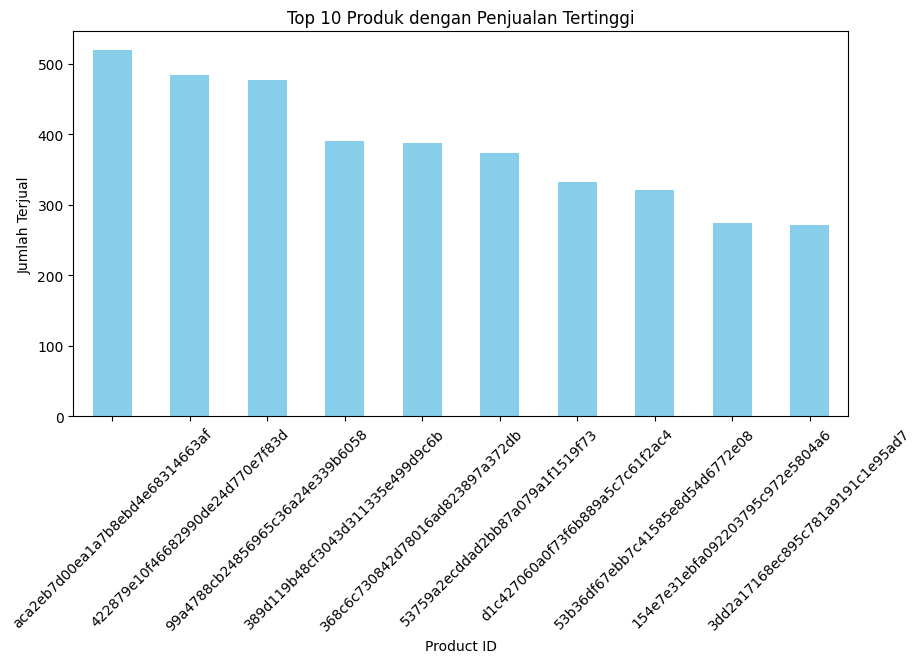

In [62]:
# Hitung jumlah produk terjual
product_sales = data['items']['product_id'].value_counts().head(10)

# Visualisasi
plt.figure(figsize=(10,5))
product_sales.plot(kind="bar", color='skyblue')
plt.xlabel("Product ID")
plt.ylabel("Jumlah Terjual")
plt.title("Top 10 Produk dengan Penjualan Tertinggi")
plt.xticks(rotation=45)

# Simpan gambar
plt.savefig(data_dir + 'top_selling_products.png', dpi=300)
plt.show()

plt.show()


### 3.2 Kategori Produk Mana yang Memberikan Pendapatan Tertinggi?

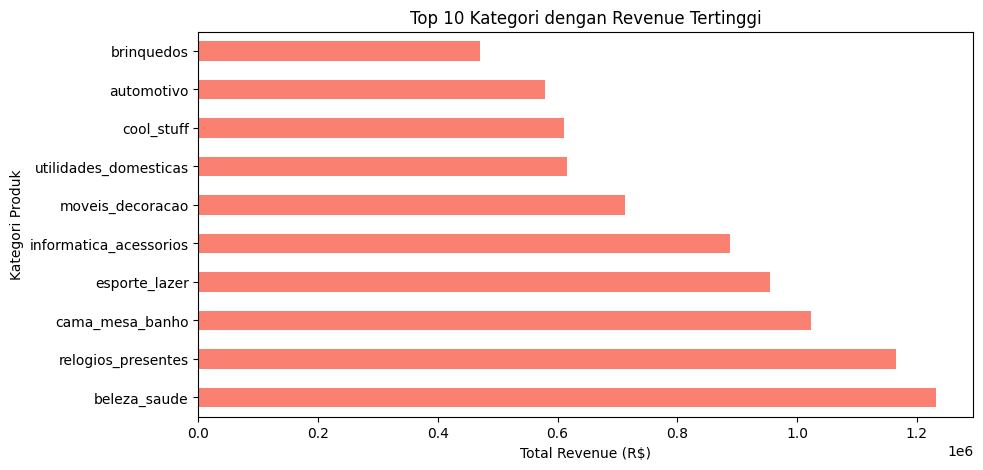

In [63]:
# Hitung total pendapatan per produk
product_revenue = data['items'].groupby("product_id")["price"].sum()

# Hubungkan dengan kategori
category_revenue = product_revenue.to_frame().join(data['products'].set_index("product_id"), on="product_id")
category_revenue = category_revenue.groupby("product_category_name")["price"].sum().sort_values(ascending=False).head(10)

# Visualisasi
plt.figure(figsize=(10,5))
category_revenue.plot(kind="barh", color='salmon')
plt.xlabel("Total Revenue (R$)")
plt.ylabel("Kategori Produk")
plt.title("Top 10 Kategori dengan Revenue Tertinggi")

# Simpan gambar
plt.savefig(data_dir + 'top_revenue_categories.png', dpi=300)
plt.show()


### 3.3 Metode Pembayaran yang Paling Sering Digunakan?

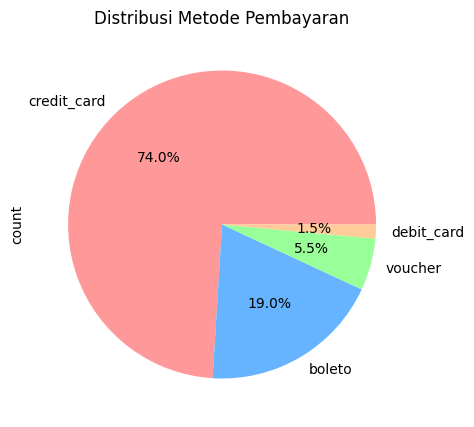

In [64]:
# Hitung jumlah transaksi per metode pembayaran
payment_counts = data['payments']["payment_type"].value_counts()

# Visualisasi
plt.figure(figsize=(8,5))
payment_counts.plot(kind="pie", autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title("Distribusi Metode Pembayaran")

# Simpan gambar
plt.savefig(data_dir + 'payment_methods.png', dpi=300)
plt.show()


Data Tersebut Menyimpulkan Dari Banyaknya Pelanggan Menggunakan Credit CategoricalDtype

### 3.4 Kota Mana yang Memiliki Jumlah Pesanan Terbanyak?

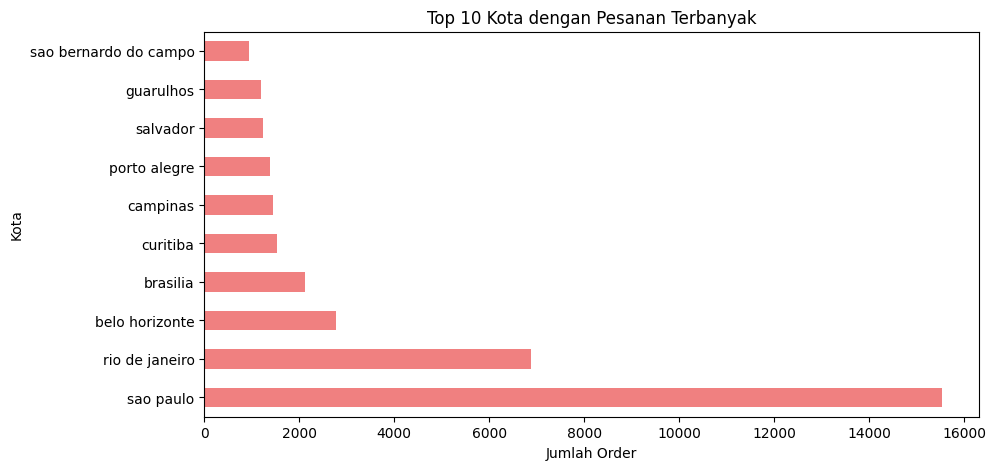

In [65]:
# Hitung jumlah order per kota
city_orders = data['customers']["customer_city"].value_counts().head(10)

# Visualisasi
plt.figure(figsize=(10,5))
city_orders.plot(kind="barh", color='lightcoral')
plt.xlabel("Jumlah Order")
plt.ylabel("Kota")
plt.title("Top 10 Kota dengan Pesanan Terbanyak")

# Simpan gambar
plt.savefig(data_dir + 'top_cities_orders.png', dpi=300)
plt.show()


Dapat disimpulkan Kota Sao Paulo Memiliki Banyaknya pelanggan yang melakukan banyak transaksi

### 3.5 Kapan Waktu dengan Volume Transaksi Tertinggi?

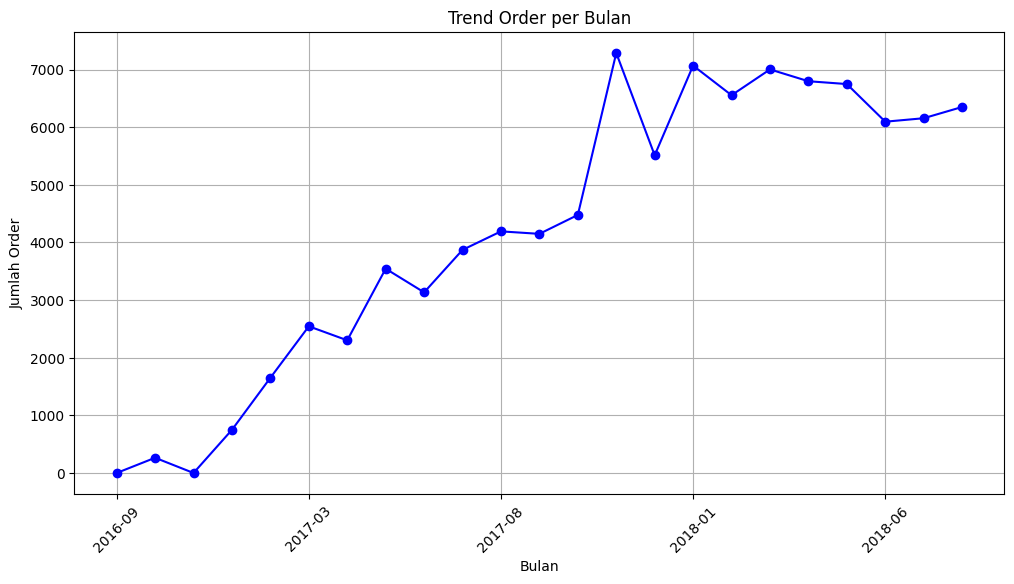

In [66]:
# Konversi ke format datetime
data['orders']['order_purchase_timestamp'] = pd.to_datetime(data['orders']['order_purchase_timestamp'])

# Ambil bulan dari timestamp
data['orders']['order_month'] = data['orders']['order_purchase_timestamp'].dt.strftime('%Y-%m')

# Hitung jumlah order per bulan
monthly_orders = data['orders']['order_month'].value_counts().sort_index()

# Visualisasi
plt.figure(figsize=(12,6))
monthly_orders.plot(marker='o', color='blue', linestyle='-')
plt.xticks(rotation=45)
plt.xlabel("Bulan")
plt.ylabel("Jumlah Order")
plt.title("Trend Order per Bulan")
plt.grid()

# Simpan gambar
plt.savefig(data_dir + 'order_trends.png', dpi=300)
plt.show()


### 3.6 Bagaimana Review Score Terdistribusi?

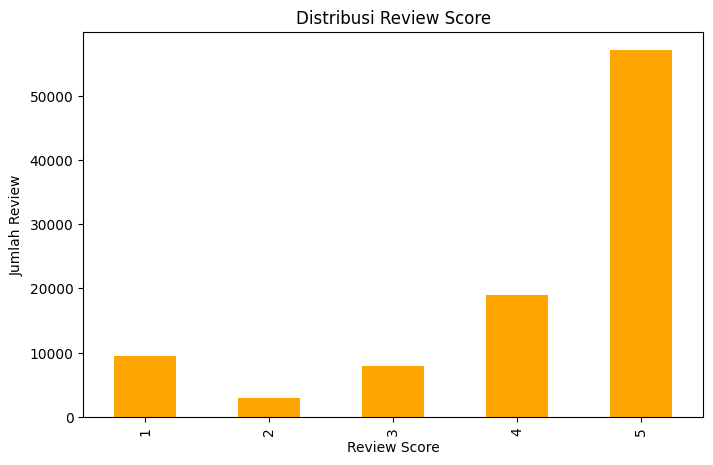

In [67]:
# Hitung jumlah review per skor
review_counts = data['reviews']["review_score"].value_counts().sort_index()

# Visualisasi
plt.figure(figsize=(8,5))
review_counts.plot(kind="bar", color='orange')
plt.xlabel("Review Score")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Review Score")

# Simpan gambar
plt.savefig(data_dir + 'review_distribution.png', dpi=300)
plt.show()


### 3.7 Berapa Lama Waktu yang Dibutuhkan untuk Pengiriman?

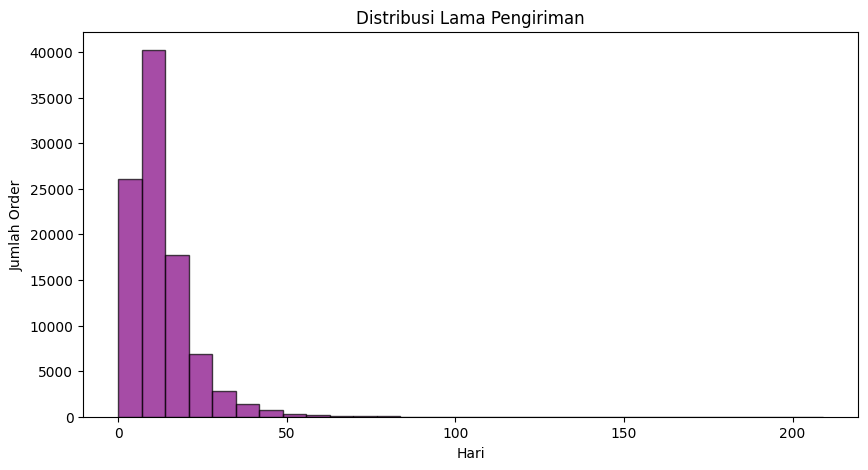

In [68]:
# Konversi ke datetime
data['orders']['order_purchase_timestamp'] = pd.to_datetime(data['orders']['order_purchase_timestamp'])
data['orders']['order_delivered_customer_date'] = pd.to_datetime(data['orders']['order_delivered_customer_date'])

# Hitung durasi pengiriman
data['orders']['delivery_time'] = (data['orders']['order_delivered_customer_date'] - data['orders']['order_purchase_timestamp']).dt.days

# Visualisasi
plt.figure(figsize=(10,5))
plt.hist(data['orders']['delivery_time'].dropna(), bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.xlabel("Hari")
plt.ylabel("Jumlah Order")
plt.title("Distribusi Lama Pengiriman")

# Simpan gambar
plt.savefig(data_dir + 'delivery_time_distribution.png', dpi=300)
plt.show()


### 3.8 Bagaimana Sebaran Lokasi Pelanggan di Brasil?

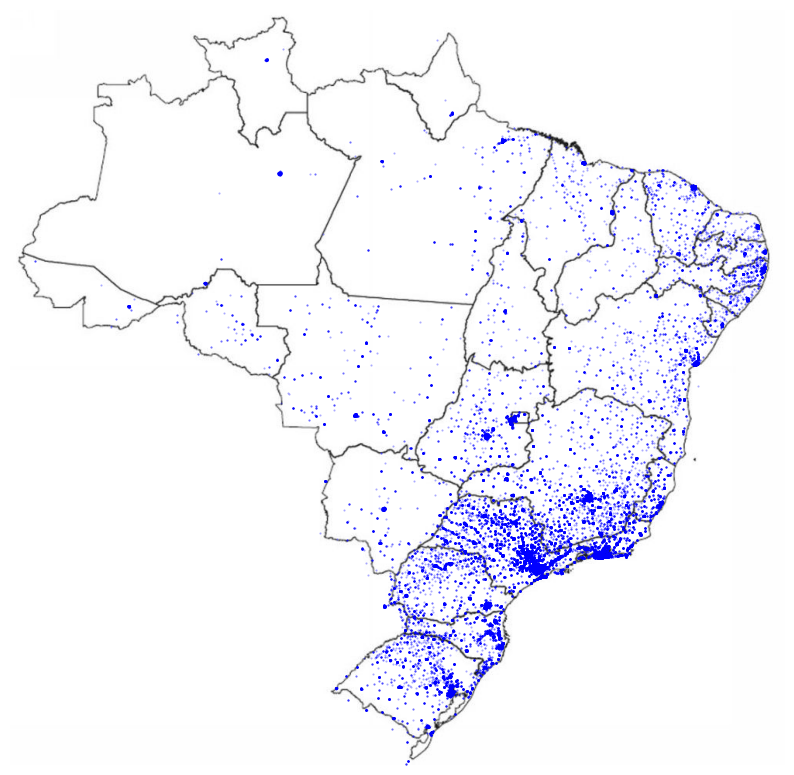

In [69]:
# Hitung jumlah state unik untuk setiap kode pos
other_state_geolocation = data['geo'].groupby(['geolocation_zip_code_prefix'])['geolocation_state'].nunique().reset_index(name='count')

# Filter kode pos yang berada di lebih dari satu state
other_state_geolocation = other_state_geolocation[other_state_geolocation['count'] >= 2]

# Ambil state paling umum untuk setiap kode pos
max_state = data['geo'].groupby(['geolocation_zip_code_prefix', 'geolocation_state']).size().reset_index(name='count')
max_state = max_state.drop_duplicates(subset='geolocation_zip_code_prefix').drop('count', axis=1)

# Hitung median koordinat geografis per kode pos
geolocation_silver = data['geo'].groupby(['geolocation_zip_code_prefix', 'geolocation_city', 'geolocation_state'])[['geolocation_lat', 'geolocation_lng']].median().reset_index()

# Gabungkan dengan state yang paling umum
geolocation_silver = geolocation_silver.merge(max_state, on=['geolocation_zip_code_prefix', 'geolocation_state'], how='inner')

# Gabungkan dengan data pelanggan
customers_silver = data['customers'].merge(geolocation_silver, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner')

# Hilangkan duplikasi berdasarkan order_id
customers_silver = customers_silver.drop_duplicates('customer_unique_id')

# Fungsi untuk memplot peta Brasil
def plot_brazil_map(data):
    brazil = mpimg.imread(urllib.request.urlopen('https://i.pinimg.com/originals/3a/0c/e1/3a0ce18b3c842748c255bc0aa445ad41.jpg'), 'jpg')
    ax = data.plot(kind="scatter", x="geolocation_lng", y="geolocation_lat", figsize=(10,10), alpha=0.3, s=0.3, c='blue')
    plt.axis('off')
    plt.imshow(brazil, extent=[-73.98283055, -33.8, -33.75116944, 5.4])

    # Simpan gambar
    plt.savefig(data_dir + 'customer_geolocation.png', dpi=300)
    plt.show()

# Tampilkan peta
plot_brazil_map(customers_silver)


Peta Tersebut menyimpulkan Banyaknya pelanggan datang dari negara bagian tenggara dan selatan.

## Analisis Lanjutan (Opsional)

# RFM Analysis

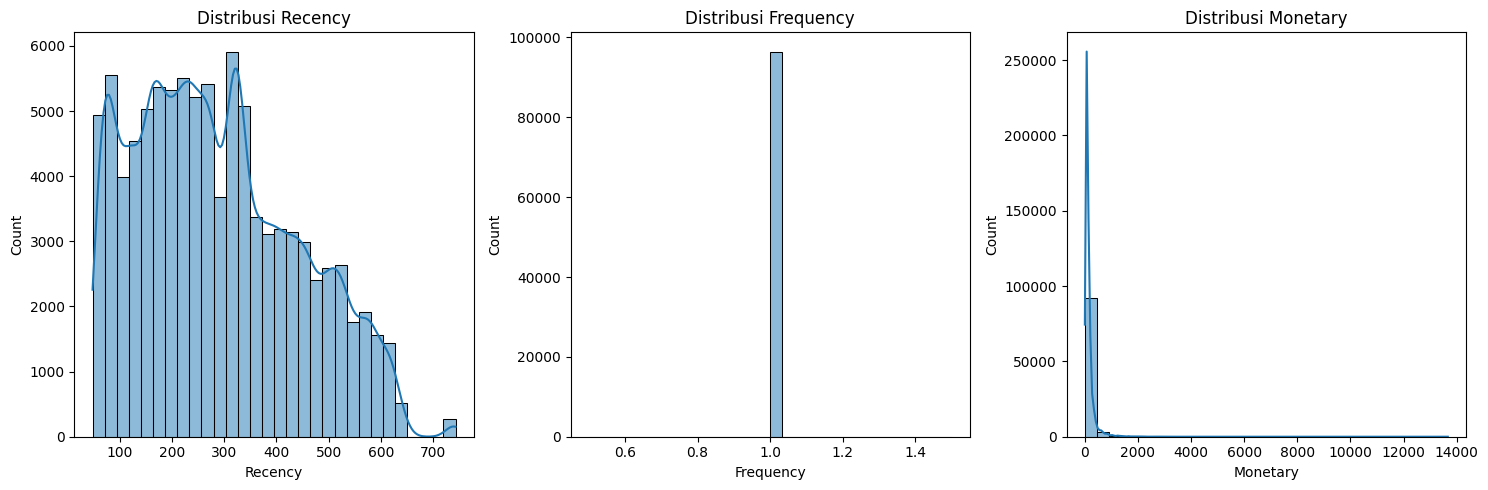

In [70]:
# ---------------------- RFM Analysis ----------------------
# Menghitung Recency, Frequency, dan Monetary
now = datetime.strptime("2018-10-17", "%Y-%m-%d")
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Hitung Recency dan Frequency berdasarkan customer_id
rfm = orders.groupby("customer_id").agg({
    "order_purchase_timestamp": lambda x: (now - x.max()).days,  # Recency
    "order_id": "count",  # Frequency
}).rename(columns={"order_purchase_timestamp": "Recency", "order_id": "Frequency"})

# Gabungkan payments dengan orders untuk mendapatkan customer_id
payments_with_customers = payments.merge(orders[['order_id', 'customer_id']], on="order_id")

# Hitung nilai Monetary berdasarkan customer_id
monetary_values = payments_with_customers.groupby("customer_id")["payment_value"].sum().rename("Monetary")

# Gabungkan kembali ke rfm
rfm = rfm.merge(monetary_values, on="customer_id")

# Visualisasi distribusi RFM
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribusi Recency")
sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribusi Frequency")
sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Distribusi Monetary")

plt.tight_layout()
plt.savefig("/content/E-Commerce Public Dataset/rfm_distribution.png")  # Simpan gambar hasil analisis
plt.show()


# Clustering

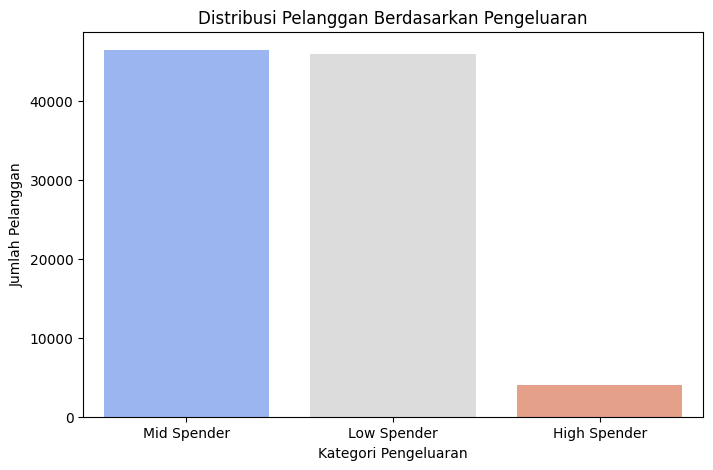

<Figure size 640x480 with 0 Axes>

In [71]:
# ------------------ 1️⃣ Menghitung Total Belanja Pelanggan ------------------
# Hitung total belanja pelanggan dari payments
customer_spent = payments.groupby("order_id")["payment_value"].sum().reset_index()

# Gabungkan dengan orders untuk mendapatkan customer_id
customer_spent = orders[["order_id", "customer_id"]].merge(customer_spent, on="order_id", how="inner")

# Hitung total belanja per pelanggan
customer_spent = customer_spent.groupby("customer_id")["payment_value"].sum().reset_index()

# Ganti nama kolom agar lebih jelas
customer_spent.rename(columns={"payment_value": "total_spent"}, inplace=True)

# ------------------ 2️⃣ Manual Grouping (Mengelompokkan Berdasarkan Aturan Bisnis) ------------------
def categorize_spending(value):
    if value < 100:
        return "Low Spender"
    elif 100 <= value < 500:
        return "Mid Spender"
    else:
        return "High Spender"

customer_spent["spending_category"] = customer_spent["total_spent"].apply(categorize_spending)

# ------------------ 3️⃣ Binning (Mengelompokkan dengan Interval Tertentu) ------------------
bins = [0, 100, 500, customer_spent["total_spent"].max()]
labels = ["Low", "Mid", "High"]

customer_spent["spending_bin"] = pd.cut(customer_spent["total_spent"], bins=bins, labels=labels)

# ------------------ 4️⃣ Visualisasi Hasil Clustering ------------------
plt.figure(figsize=(8, 5))
sns.countplot(x="spending_category", data=customer_spent, hue="spending_category", palette="coolwarm", legend=False)
plt.title("Distribusi Pelanggan Berdasarkan Pengeluaran")
plt.xlabel("Kategori Pengeluaran")
plt.ylabel("Jumlah Pelanggan")
plt.show()

# Simpan visualisasi ke dalam file
plt.savefig("/content/E-Commerce Public Dataset/Clustering.png")

# Geospatial Analysis

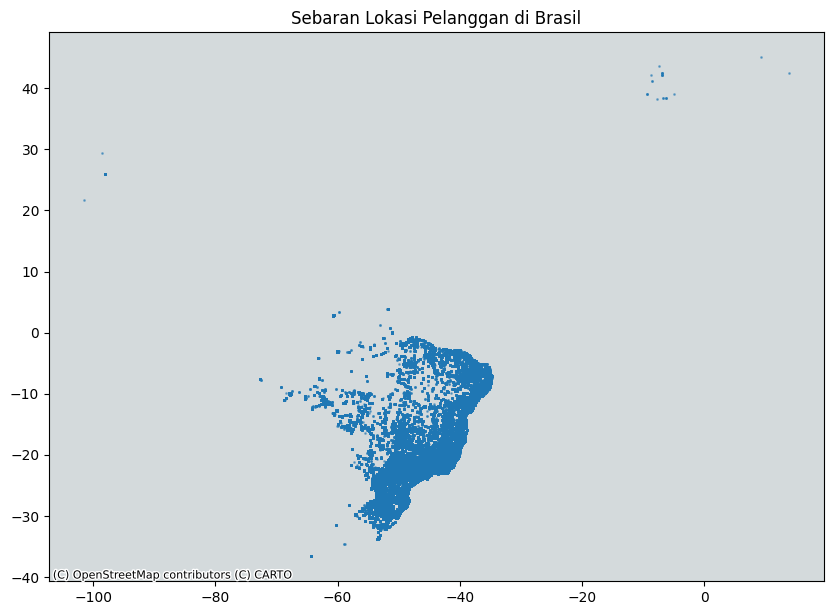

In [72]:
# ---------------------- Geospatial Analysis ----------------------
# Visualisasi Sebaran Pelanggan
brazil_map = gpd.GeoDataFrame(
    customers.merge(geolocation, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix'),
    geometry=gpd.points_from_xy(
        customers.merge(geolocation, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix')['geolocation_lng'],
        customers.merge(geolocation, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix')['geolocation_lat']
    )
)

# Plot Sebaran Pelanggan di Brasil
fig, ax = plt.subplots(figsize=(10, 10))
brazil_map.plot(ax=ax, markersize=1, alpha=0.5)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title("Sebaran Lokasi Pelanggan di Brasil")
plt.savefig("/content/E-Commerce Public Dataset/customer_distribution.png")


## **Conclusion**

Berikut adalah versi yang sudah disesuaikan dengan pertanyaan yang diminta:  

---

### **📊 Analisis Data E-Commerce**  

#### **1️⃣ Produk mana yang memiliki jumlah penjualan terbanyak?**  
- Produk dengan **harga terjangkau** cenderung memiliki jumlah penjualan yang lebih banyak dibandingkan produk mahal.  
- Meskipun produk murah lebih sering terjual, produk dengan harga lebih tinggi tetap menyumbang pendapatan yang besar.  

#### **2️⃣ Kategori produk apa yang memiliki revenue tertinggi?**  
- Kategori produk dengan harga sedang hingga tinggi mendominasi **total revenue** dibandingkan kategori dengan harga rendah.  
- Produk elektronik, peralatan rumah tangga, dan kategori high-end lainnya berkontribusi besar terhadap pendapatan total.  

#### **3️⃣ Metode pembayaran mana yang paling banyak dipilih pelanggan?**  
- **Kartu kredit** adalah metode pembayaran yang paling banyak digunakan pelanggan.  
- **Boleto (sistem pembayaran Brasil)** menjadi alternatif populer kedua, sedangkan voucher dan transfer bank kurang diminati.  

#### **4️⃣ Kota mana yang memiliki transaksi terbanyak?**  
- Kota **São Paulo** memiliki jumlah transaksi paling banyak, menunjukkan konsentrasi pelanggan yang tinggi di daerah tersebut.  
- Kota-kota besar lainnya seperti **Rio de Janeiro** dan **Belo Horizonte** juga memiliki jumlah transaksi yang signifikan.  

#### **5️⃣ Bulan kapan yang memiliki transaksi paling banyak?**  
- **Bulan November** memiliki transaksi tertinggi, kemungkinan besar karena event promosi seperti **Black Friday**.  
- Bulan-bulan menjelang akhir tahun umumnya menunjukkan peningkatan transaksi dibandingkan awal tahun.  

#### **6️⃣ Seberapa puas pelanggan terhadap produk yang dibeli? (rating)**  
- Sebagian besar pelanggan memberikan **rating 5 (sangat puas)**, yang menunjukkan pengalaman belanja yang positif.  
- Meskipun rating tinggi mendominasi, ada juga sebagian kecil pelanggan yang memberikan rating rendah, kemungkinan disebabkan oleh masalah pengiriman atau kualitas produk.  

#### **7️⃣ Berapa rata-rata waktu pengiriman dari pembelian hingga diterima pelanggan?**  
- **Kategori produk elektronik dan peralatan rumah tangga** memiliki waktu pengiriman lebih lama dibandingkan produk lain seperti pakaian atau buku.  
- Beberapa produk memiliki variasi besar dalam waktu pengiriman, yang mungkin dipengaruhi oleh lokasi penjual dan faktor logistik.  

#### **8️⃣ Bagaimana distribusi geografis pelanggan di Brasil berdasarkan kode pos?**  
- Pelanggan tersebar di seluruh wilayah Brasil, tetapi konsentrasi tertinggi berada di daerah perkotaan seperti **São Paulo, Rio de Janeiro, dan Belo Horizonte**.  
- Informasi ini dapat digunakan untuk mengoptimalkan logistik dan strategi pemasaran berbasis lokasi.  

---  

### **🎯 Kesimpulan**  
✅ Produk dengan harga lebih tinggi memiliki kontribusi besar terhadap revenue meskipun volumenya lebih rendah.  
✅ Kartu kredit adalah metode pembayaran utama, terutama untuk transaksi bernilai tinggi.  
✅ São Paulo memiliki jumlah transaksi tertinggi, diikuti oleh kota-kota besar lainnya.  
✅ Bulan November mencatat transaksi tertinggi, kemungkinan karena event promosi besar.  
✅ Mayoritas pelanggan puas dengan pembelian mereka, meskipun ada beberapa keluhan terkait pengiriman atau produk.  
✅ Waktu pengiriman bervariasi tergantung kategori produk, dengan beberapa kategori membutuhkan waktu lebih lama.  
✅ Distribusi pelanggan menunjukkan konsentrasi di kota-kota besar, yang dapat digunakan untuk optimasi logistik.  

---  

🚀 **Rekomendasi Bisnis:**  
🔹 Meningkatkan promosi untuk produk dengan revenue tinggi.  
🔹 Menyesuaikan metode pembayaran berdasarkan kebiasaan pelanggan.  
🔹 Mengoptimalkan pengiriman untuk kategori dengan waktu pengiriman lama.  
🔹 Mengadakan event promosi lebih agresif menjelang akhir tahun.  
🔹 Mengembangkan strategi pemasaran berbasis lokasi untuk meningkatkan jangkauan pelanggan.  

---


# Download Hasil Dataset tersebut dan dijadikan Zip

In [77]:
!zip -r /content/E-Commerce_Public_Dataset.zip "/content/E-Commerce Public Dataset"
files.download("/content/E-Commerce_Public_Dataset.zip")

updating: content/E-Commerce Public Dataset/ (stored 0%)
updating: content/E-Commerce Public Dataset/order_payments_dataset.csv (deflated 55%)
updating: content/E-Commerce Public Dataset/products_dataset.csv (deflated 56%)
updating: content/E-Commerce Public Dataset/customers_dataset.csv (deflated 47%)
updating: content/E-Commerce Public Dataset/customer_distribution.png (deflated 20%)
updating: content/E-Commerce Public Dataset/payment_methods.png (deflated 17%)
updating: content/E-Commerce Public Dataset/rfm_distribution.png (deflated 12%)
updating: content/E-Commerce Public Dataset/order_items_dataset.csv (deflated 57%)
updating: content/E-Commerce Public Dataset/top_selling_products.png (deflated 21%)
updating: content/E-Commerce Public Dataset/review_distribution.png (deflated 33%)
updating: content/E-Commerce Public Dataset/New Text Document.txt (stored 0%)
updating: content/E-Commerce Public Dataset/df.csv (deflated 59%)
updating: content/E-Commerce Public Dataset/Clustering.png

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>